# Simulate, Summarize, Reduce, Cluster, and Analyze (SSRCA) methodology

Similar to [Rohr & Nardini 2026](https://doi.org/10.1007/s11538-026-01604-8), we apply SSRCA methodology in this jupyter notebook.

***Simulate***: Simulations were obtain from Sobol sequence sampling and stored in [Simulations.db](./Simulations.db).

***Summarize***: The simulations can be summarized using custom lambda function defined here.

In [1]:
from uq_physicell.model_analysis import calculate_qoi_from_db_file, get_summary_statistics_qois

import os
import numpy as np
import pandas as pd
import scipy
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

def calculate_spatial_qois(points):
    """
    points: Nx2 array of (x, y) coordinates for all living cells
    """
    # 1. Voronoi Area CV (The Pressure Sensor)
    vor = scipy.spatial.Voronoi(points)
    areas = []
    for i, region_idx in enumerate(vor.point_region):
        region = vor.regions[region_idx]
        if -1 in region or len(region) == 0: 
            # Skip infinite/incomplete regions at the tumor edge
            continue
        # Calculate area of polygon using Shoelace Formula
        polygon = vor.vertices[region]
        area = 0.5 * np.abs(np.dot(polygon[:,0], np.roll(polygon[:,1], 1)) - 
                            np.dot(polygon[:,1], np.roll(polygon[:,0], 1)))
        areas.append(area)
    vor_cv = np.std(areas) / np.mean(areas) if areas else 0
    # 2. Convex Hull Ratio (The Solidity Sensor)
    hull = scipy.spatial.ConvexHull(points)
    # Note: hull.volume is Area in 2D
    # Actual area can be approximated by sum of Voronoi areas or 
    # the area of an Alpha Shape if the tumor is porous.
    total_vor_area = np.sum(areas) 
    solidity = total_vor_area / hull.volume 
    return {
        "voronoi_cv": vor_cv,
        "solidity": solidity,
        "convex_hull_area": hull.volume
    }

def radial_density_summary(points, bin_size=20.0, max_dist=500.0):
    """Extract summary statistics from radial distribution instead of raw bins"""
    center = np.mean(points, axis=0)
    dist_from_center = np.linalg.norm(points - center, axis=1)
    
    return {
        "radial_center_of_mass": np.average(dist_from_center),
        "radial_median": np.median(dist_from_center),
        "radial_spread": np.std(dist_from_center),
        "radial_iqr": np.percentile(dist_from_center, 75) - np.percentile(dist_from_center, 25),
        "radial_skewness": scipy.stats.skew(dist_from_center),
        "radial_kurtosis": scipy.stats.kurtosis(dist_from_center),
    }

db_file = 'Simulations.db'
qoi_funcs = {
    # Kinetic and global QoIs
    'live_cell_count': lambda df: len( df[ df['dead'] == False ]),
    'dead_cell_count': lambda df: len( df[ df['dead'] == True ]),
    'sum_live_cell_count': lambda mcds_ts: sum(map(lambda mcds: len(mcds.get_cell_df()[mcds.get_cell_df()['dead'] == False]), mcds_ts)),
    'sum_dead_cell_count': lambda mcds_ts: sum(map(lambda mcds: len(mcds.get_cell_df()[mcds.get_cell_df()['dead'] == True]), mcds_ts)),
    'tumor_radius': lambda df:  ( (df['position_x'].max() - df['position_x'].min())**2 + (df['position_y'].max() - df['position_y'].min())**2 )**0.5, 
    # Spatial Architecture Metrics ("pressure sensors")
    'spatial_architecture': lambda df: calculate_spatial_qois(df[['position_x', 'position_y']].values),
    # Radial Density Metrics ("solidity sensors")
    'radial_density': lambda df: radial_density_summary(df[['position_x', 'position_y']].values)

}

df_all_file_dataset = 'QoIs_all.parquet' 
df_qois_file_mean = 'QoIs_mean.parquet'
df_qois_file_std = 'QoIs_std.parquet'
df_qois_file_mcse = 'QoIs_mcse.parquet'
if os.path.exists(df_all_file_dataset):
    df_all_dataset = pd.read_parquet(df_all_file_dataset)
    df_qois_mean = pd.read_parquet(df_qois_file_mean)
    df_qois_std = pd.read_parquet(df_qois_file_std)
    df_qois_mcse = pd.read_parquet(df_qois_file_mcse)
else:
    chunk_size = 100
    df_all_dataset = calculate_qoi_from_db_file(db_file, qoi_funcs, qoi_def={'spatial_architecture': calculate_spatial_qois, 'radial_density': radial_density_summary}, chunk_size=chunk_size)
    df_qois_mean, df_qois_std, df_qois_mcse = get_summary_statistics_qois(df_all_dataset)
    # Save dataframes
    df_qois_mean.to_parquet(df_qois_file_mean)
    df_qois_std.to_parquet(df_qois_file_std)
    df_qois_mcse.to_parquet(df_qois_file_mcse)
    df_all_dataset.to_parquet(df_all_file_dataset)

# df_all_dataset.drop(columns=['sum_live_cell_count', 'sum_dead_cell_count'], inplace=True) # Remove redundant QoI
# df_qois_mean.drop(columns=['sum_live_cell_count', 'sum_dead_cell_count'], inplace=True) # Remove redundant QoI
# df_qois_std.drop(columns=['sum_live_cell_count', 'sum_dead_cell_count'], inplace=True) # Remove redundant QoI
# df_qois_mcse.drop(columns=['sum_live_cell_count', 'sum_dead_cell_count'], inplace=True) # Remove redundant QoI

# Compute net growth rate as d(live_cell_count)/dt for each SampleID
# df_qois_mean = df_qois_mean.sort_index()
# time_delta = (
#     df_qois_mean.index.get_level_values('time')
#     .to_series(index=df_qois_mean.index)
#     .groupby(level='SampleID')
#     .diff()
#     .replace(0, np.nan)
# )
# live_count_delta = df_qois_mean.groupby(level='SampleID')['live_cell_count'].diff()
# df_qois_mean['net_growth_rate'] = (
#     live_count_delta.div(time_delta).replace([np.inf, -np.inf], np.nan).fillna(0.0)
#  )
# df_qois_mean['death_fraction'] = df_qois_mean['dead_cell_count'] / df_qois_mean['live_cell_count']
# # Add to mcse dataframe as well
# df_qois_mcse['net_growth_rate'] = df_qois_mean['net_growth_rate'] * np.sqrt( (df_qois_mcse['live_cell_count'] / df_qois_mean['live_cell_count'])**2 )
# df_qois_mcse['death_fraction'] = df_qois_mean['death_fraction'] * np.sqrt( (df_qois_mcse['dead_cell_count'] / df_qois_mean['dead_cell_count'])**2 + (df_qois_mcse['live_cell_count'] / df_qois_mean['live_cell_count'])**2 )


display(df_qois_mean)

dead_cell_count  live_cell_count  \
SampleID time                                       
0        0.0                 0.0            511.0   
         240.0               6.8            582.6   
         480.0              13.2            632.4   
         720.0              15.6            673.6   
         960.0              18.0            712.0   
...                          ...              ...   
47       6240.0             44.0           1869.4   
         6480.0             48.4           1933.4   
         6720.0             45.2           2004.6   
         6960.0             47.2           2078.8   
         7200.0             50.6           2147.0   

                 radial_center_of_mass_radial_density  \
SampleID time                                           
0        0.0                               133.138475   
         240.0                             133.901698   
         480.0                             136.789895   
         720.0                             141.141436   
         960.0                             145.441478   
...                                               ...   
47       6240.0                            234.405082   
         6480.0                            238.622213   
         6720.0                            242.651780   
         6960.0                            247.164948   
         7200.0                            251.039230   

                 radial_iqr_radial_density  radial_kurtosis_radial_density  \
SampleID time                                                                
0        0.0                     72.351901                       -0.601573   
         240.0                   72.537136                       -0.591751   
         480.0                   76.049185                       -0.618111   
         720.0                   77.876381                       -0.616012   
         960.0                   80.678351                       -0.627665   
...                                    ...                             ...   
47       6240.0                 129.649753                       -0.617498   
         6480.0                 131.728460                       -0.616802   
         6720.0                 133.797947                       -0.613451   
         6960.0                 136.461236                       -0.617948   
         7200.0                 138.916625                       -0.619543   

                 radial_median_radial_density  radial_skewness_radial_density  \
SampleID time                                                                   
0        0.0                       141.328870                       -0.564466   
         240.0                     141.950126                       -0.557403   
         480.0                     144.833029                       -0.533908   
         720.0                     149.496105                       -0.528523   
         960.0                     153.541930                       -0.517701   
...                                       ...                             ...   
47       6240.0                    247.914279                       -0.519880   
         6480.0                    251.885800                       -0.520141   
         6720.0                    256.311106                       -0.523749   
         6960.0                    261.149170                       -0.523198   
         7200.0                    265.473669                       -0.521889   

                 radial_spread_radial_density  \
SampleID time                                   
0        0.0                        47.075566   
         240.0                      47.351749   
         480.0                      49.034745   
         720.0                      50.490589   
         960.0                      52.114448   
...                                       ...   
47       6240.0                     83.831650   
         6480.0                     85.364164   
         6720.0           

## Replicate Check (MCSE)

Decide if we have a stable "signature" for the QoIs.

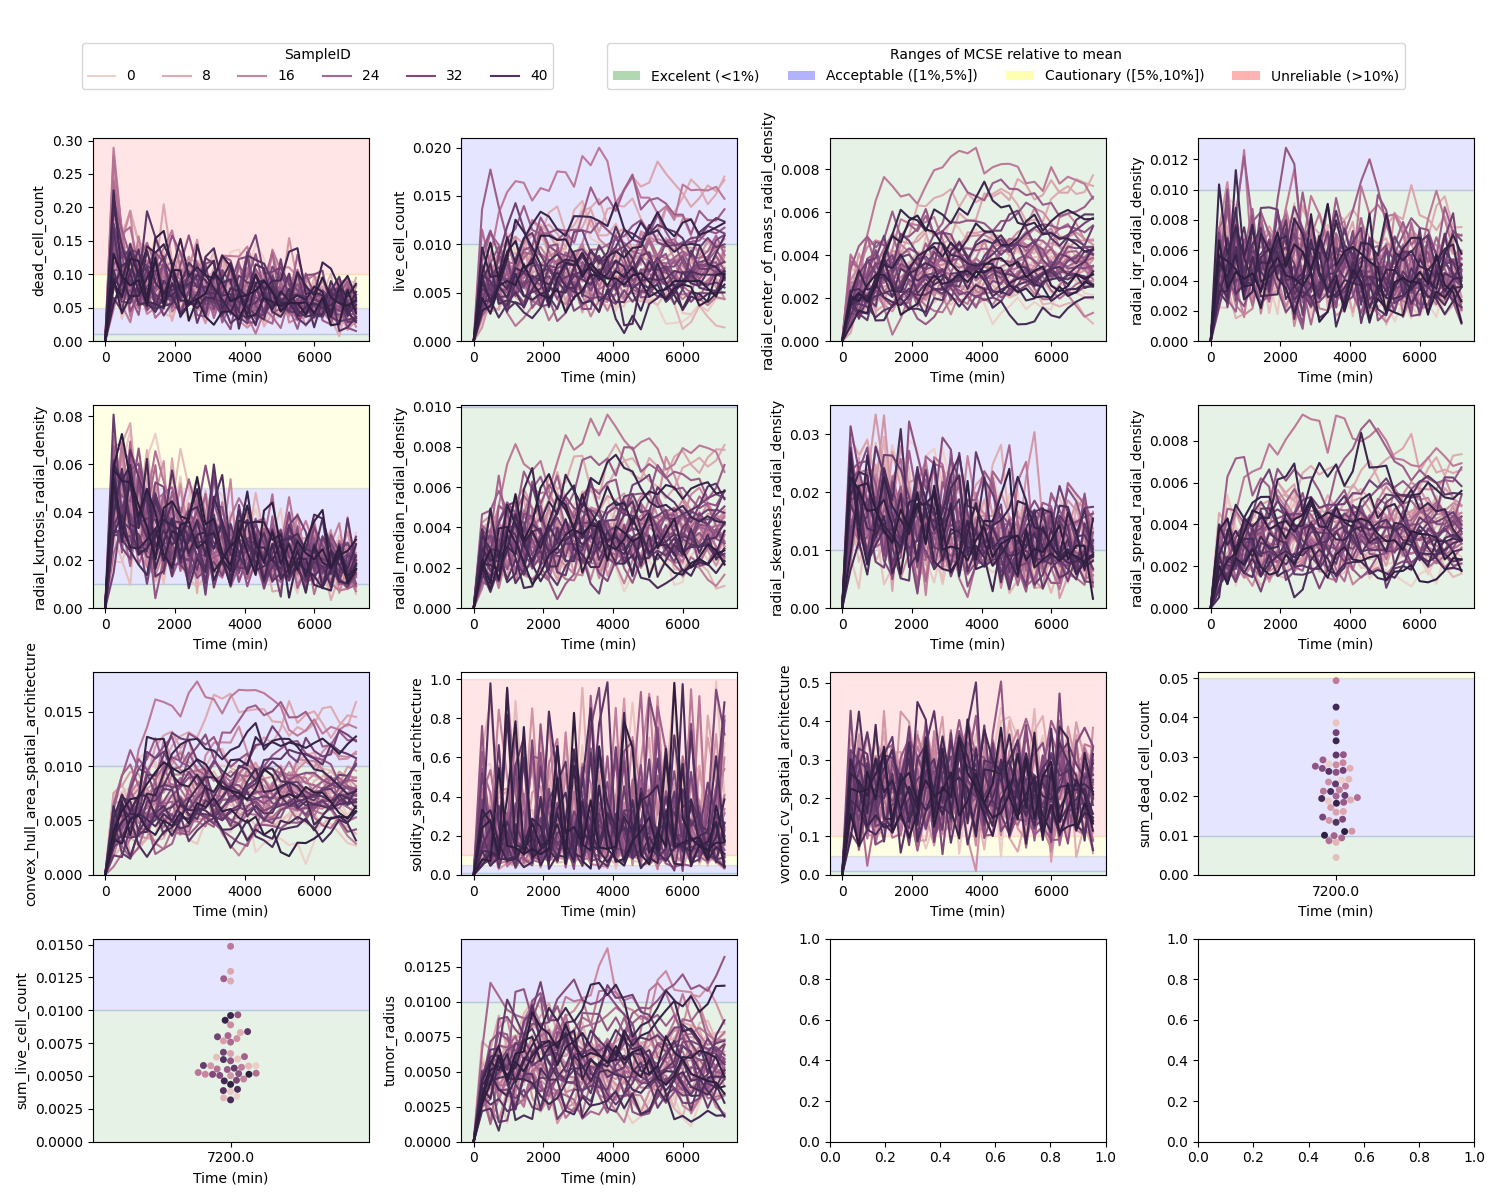

In [2]:
import matplotlib.pyplot as plt
from matplotlib.legend import Legend
from uq_physicell.model_analysis import plot_qoi_over_time

# Prevent notebook inline backend from tight-cropping artists outside the axes
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}
qois_names = [col for col in df_qois_mean.columns]

fig, axes = plt.subplots(4, 4, figsize=(15, 12))
axes = axes.flatten()
for ax_id, qoi_name in enumerate(qois_names):
    ax = axes[ax_id]
    plot_qoi_over_time(df_qois_mcse, qoi_name, ax, plot_mcse_range=True)

# Extract legend entries, separating SampleID from MCSE to avoid duplicates
sample_pairs = {}
mcse_pairs = {}
for legend_obj in axes[0].findobj(Legend):
    legend_texts = [t.get_text() for t in legend_obj.get_texts()]
    legend_handles = legend_obj.legend_handles
    for handle, label in zip(legend_handles, legend_texts):
        # MCSE legends use percentage signs in visualization.py
        if '%' in label:  
            if label not in mcse_pairs:
                mcse_pairs[label] = handle
        # Sample legends are numeric
        elif str(label).strip().isdigit():
            if label not in sample_pairs:
                sample_pairs[label] = handle

# Hide all legends inside subplots to clean up clutter
for ax in axes:
    legend = ax.get_legend()
    if legend is not None:
        legend.set_visible(False)
        legend.set_in_layout(False)
    for legend_artist in ax.findobj(Legend):
        legend_artist.set_visible(False)
        legend_artist.set_in_layout(False)

# Add Figure-level legend for Sample IDs at the top
if sample_pairs:
    fig.legend(
        list(sample_pairs.values()),
        list(sample_pairs.keys()),
        title='SampleID',
        loc='upper left',
        ncol=min(len(sample_pairs), 10),
        bbox_to_anchor=(0.05, 0.97)
    )

# Add Figure-level legend for MCSE Ranges at the bottom
if mcse_pairs:
    fig.legend(
        list(mcse_pairs.values()),
        list(mcse_pairs.keys()),
        title='Ranges of MCSE relative to mean',
        loc='upper left',
        ncol=4,
        bbox_to_anchor=(0.40, 0.97)
    )

# Leave space at the top and bottom of the plot explicitly
plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.savefig('QoI_Results.svg', format='svg', bbox_inches='tight')
plt.show()

In [3]:
from uq_physicell.model_analysis import load_samples
from uq_physicell.model_analysis.utils import recursive_feature_elimination

# Load parameters indexed by SampleID
df_params = pd.DataFrame.from_dict(load_samples(db_file), orient='index').sort_index()
dic_RFE_results = recursive_feature_elimination(df_qois_mean, df_qois_mcse, df_params, verbose=True)

✓ Trajectory QoIs filled (NaN→last value per sample): ['sum_dead_cell_count', 'sum_live_cell_count']

[STAGE 1] Pathological Noise Removal (MCSE > 10.0%)
  Removed 3 pathological features: ['dead_cell_count', 'solidity_spatial_architecture', 'voronoi_cv_spatial_architecture']

[STAGE 2] Redundancy Removal (Correlation > 95.0%)
  Removed 6 redundant features: ['live_cell_count', 'radial_iqr_radial_density', 'radial_median_radial_density', 'radial_spread_radial_density', 'convex_hull_area_spatial_architecture', 'tumor_radius']

[STAGE 3] Autoencoder on Cleaned Features (5 QoIs)
Using PyTorch autoencoder
AE epoch 1/200 loss=0.982017
AE epoch 21/200 loss=0.274095
AE epoch 41/200 loss=0.233026
AE epoch 61/200 loss=0.225787
AE epoch 81/200 loss=0.221344
AE epoch 101/200 loss=0.218027
AE epoch 121/200 loss=0.215901
AE epoch 141/200 loss=0.213528
AE epoch 161/200 loss=0.210929
AE epoch 181/200 loss=0.208375
AE epoch 200/200 loss=0.20578
  Full AE → Params R² (mean): 0.0421

[STAGE 4] RFECV-bas

In [4]:
display(dic_RFE_results['reduced_regression_r2'])
display(dic_RFE_results['final_qois']       )

,R2_CV
apoptosis_rate,0.823871
cell_cycle_entry,0.635336


['sum_dead_cell_count', 'sum_live_cell_count']

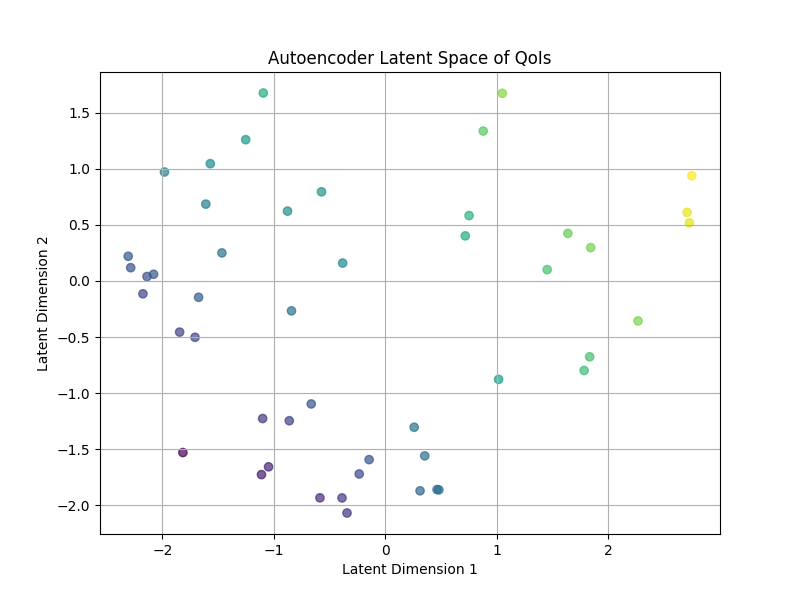

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
df_plot = df_qois_mean.reset_index()
dict_autoencoder_results = dic_RFE_results['reduced_autoencoder_results']
feature_colored = 'sum_dead_cell_count'# 'time', 'live_cell_count', 'sum_dead_cell_count'
plt.scatter(dict_autoencoder_results['encoder_output'][:, 0], dict_autoencoder_results['encoder_output'][:, 1], c=df_plot[feature_colored].to_numpy(), alpha=0.7)
plt.title('Autoencoder Latent Space of QoIs')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.grid(True)

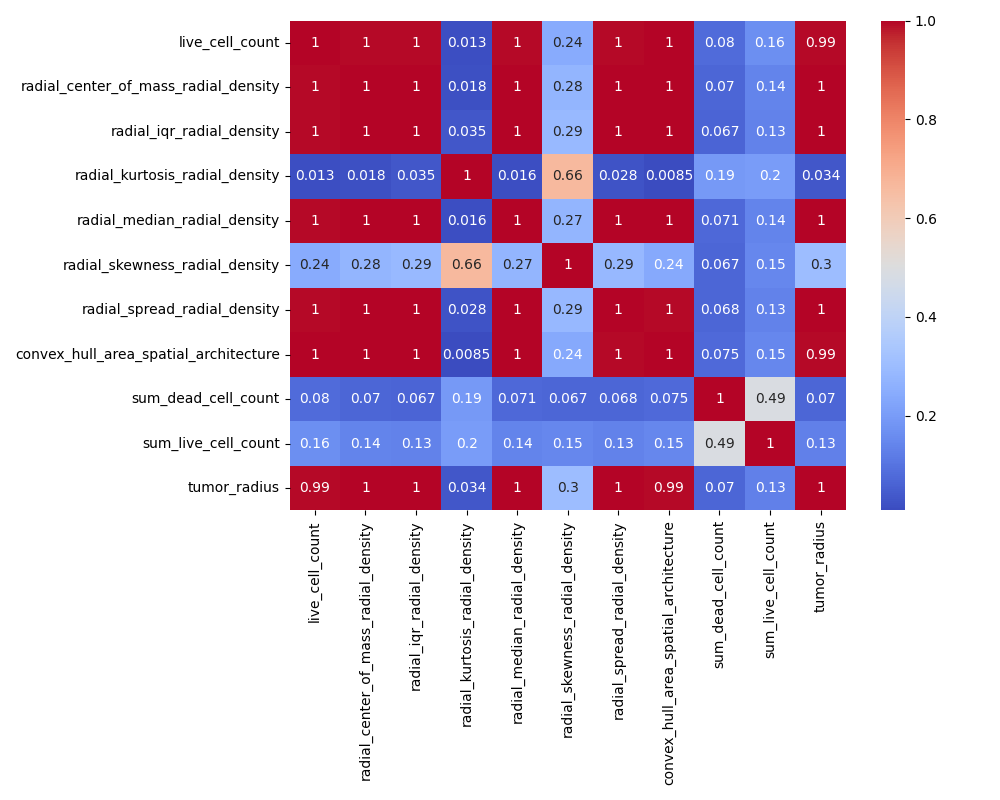

In [6]:
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(dic_RFE_results['correlation_matrix'], annot=True, cmap='coolwarm')
plt.tight_layout()